# Plot Continuous Random Time Series

This notebook loads the generated NetCDF random series and plots time series for a selected period and ensemble member.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams['figure.figsize'] = (12, 4)

candidate_paths = [
    Path('continuous_random_19000101_20260101.nc'),
    Path('continuous_random_19000101.nc'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'No NetCDF file found. Run generate_continuous_random_19000101.py first.'
    )

ds = xr.open_dataset(data_path)
print(f'Loaded: {data_path.resolve()}')
print(ds)


Loaded: /data02/shiojiri/ILS/ILS_data/ERA5_pf/perturbed_forcing/continuous_random_19000101_20260101.nc
<xarray.Dataset> Size: 804MB
Dimensions:        (time: 1104505, ensemble: 20, variable: 3)
Coordinates:
  * time           (time) datetime64[ns] 9MB 1900-01-01 ... 2026-01-01
  * ensemble       (ensemble) int32 80B 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20
  * variable       (variable) <U6 72B 'Precip' 'SWdown' 'LWdown'
Data variables:
    z_raw          (time, ensemble, variable) float32 265MB ...
    z_scaled       (time, ensemble, variable) float32 265MB ...
    factor_Precip  (time, ensemble) float32 88MB ...
    factor_SWdown  (time, ensemble) float32 88MB ...
    factor_LWdown  (time, ensemble) float32 88MB ...
Attributes:
    title:              Continuous AR(1) random sequence from 1900-01-01 00:00
    method:             pf_random Minimal iterative example parameters
    start_time:         1900-01-01 00:00:00
    end_time:           2026-01-01 00:00:00
    interval_seconds:  

In [3]:
# Dataset summary
time_start = pd.Timestamp(ds.time.values[0])
time_end = pd.Timestamp(ds.time.values[-1])
members = ds['ensemble'].values

print(f'Time coverage : {time_start} -> {time_end}')
print(f'Ensemble IDs  : {members.min()} .. {members.max()} (count={members.size})')
print('Variables    :', list(ds.data_vars))
print('Components    :', list(ds.coords['variable'].values) if 'variable' in ds.coords else 'N/A')


Time coverage : 1900-01-01 00:00:00 -> 2026-01-01 00:00:00
Ensemble IDs  : 1 .. 20 (count=20)
Variables    : ['z_raw', 'z_scaled', 'factor_Precip', 'factor_SWdown', 'factor_LWdown']
Components    : [np.str_('Precip'), np.str_('SWdown'), np.str_('LWdown')]


## Set Plot Parameters
Edit values in the next cell, then run the plotting cell.


In [13]:
# User parameters
member_ids = [1, 10, 20]
start_time = '2013-12-01 00:00:00'
end_time = '2014-01-10 00:00:00'

# Variables to plot (must exist in ds.data_vars)
plot_vars = [
    'z_raw',
    'z_scaled',
    'factor_Precip',
    'factor_SWdown',
    'factor_LWdown',
]

# Component for 3D vars with dims (time, ensemble, variable)
component = 'Precip'


In [14]:
def plot_member_timeseries(
    ds: xr.Dataset,
    member_ids: list[int],
    start_time: str,
    end_time: str,
    plot_vars: list[str],
    component: str | None = None,
) -> None:
    if 'ensemble' not in ds.coords:
        raise ValueError('Dataset has no ensemble coordinate.')

    if not member_ids:
        raise ValueError('member_ids must not be empty.')

    member_ids = [int(m) for m in member_ids]
    valid_members = set(int(m) for m in ds['ensemble'].values.tolist())
    invalid_members = [m for m in member_ids if m not in valid_members]
    if invalid_members:
        all_members = sorted(valid_members)
        raise ValueError(
            f'Invalid member_ids: {invalid_members}. Choose from {all_members[0]}..{all_members[-1]}.'
        )

    t0 = pd.Timestamp(start_time)
    t1 = pd.Timestamp(end_time)
    if t1 < t0:
        raise ValueError('end_time must be later than or equal to start_time.')

    subset = ds.sel(ensemble=member_ids, time=slice(t0, t1))
    if subset.sizes.get('time', 0) == 0:
        raise ValueError('No time steps found in the specified range.')

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(len(plot_vars), 1, figsize=(13, 2.8 * len(plot_vars)), sharex=True)
    if len(plot_vars) == 1:
        axes = [axes]

    for ax, var_name in zip(axes, plot_vars):
        if var_name not in subset.data_vars:
            raise ValueError(f'Variable not found: {var_name}')

        da = subset[var_name]
        label = var_name

        if 'variable' in da.dims:
            if component is None:
                raise ValueError(f'{var_name} has variable dimension. Set component (e.g., Precip).')
            da = da.sel(variable=component)
            label = f'{var_name}[{component}]'

        for mid in member_ids:
            if 'ensemble' in da.dims:
                y = da.sel(ensemble=mid).values
            else:
                y = da.values
            ax.plot(subset['time'].values, y, lw=1.0, label=f'member {mid}')

        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        if len(member_ids) > 1:
            ax.legend(loc='upper right', ncol=min(4, len(member_ids)), fontsize=8)

    axes[0].set_title(
        f'Time Series for members={member_ids} | {t0} to {t1}'
    )
    axes[-1].set_xlabel('time')
    fig.tight_layout()
    plt.show()


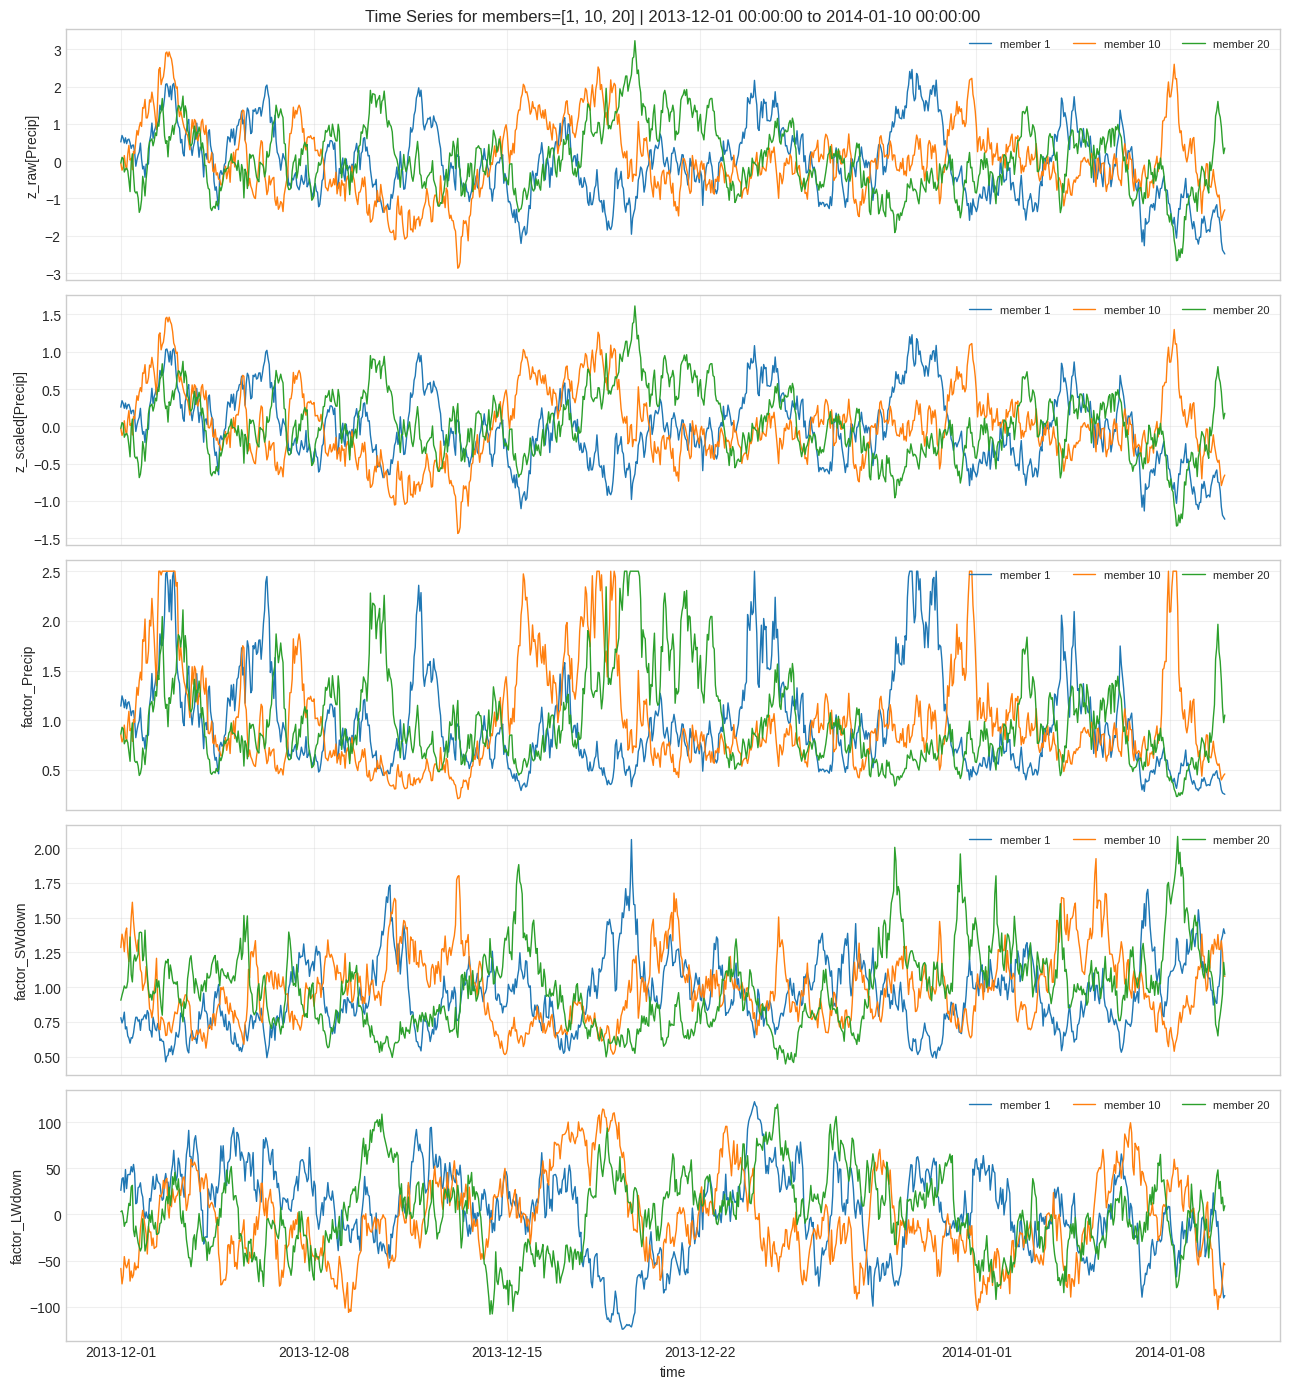

In [15]:
plot_member_timeseries(
    ds=ds,
    member_ids=member_ids,
    start_time=start_time,
    end_time=end_time,
    plot_vars=plot_vars,
    component=component,
)
